# E-commerce Business Performance Analysis

**Comprehensive analysis of e-commerce sales data with focus on revenue trends, customer behavior, and operational performance**

---

## Table of Contents

1. [Introduction & Business Objectives](#introduction)
2. [Data Dictionary](#data-dictionary)
3. [Configuration & Setup](#configuration)
4. [Data Loading & Preparation](#data-loading)
5. [Revenue Analysis](#revenue-analysis)
6. [Product Performance Analysis](#product-analysis)
7. [Geographic Performance Analysis](#geographic-analysis)
8. [Customer Experience Analysis](#customer-analysis)
9. [Operational Performance Analysis](#operational-analysis)
10. [Summary & Key Insights](#summary)

---

## 1. Introduction & Business Objectives

### Purpose
This analysis provides comprehensive insights into e-commerce business performance, focusing on:

### Key Business Questions
- **Revenue Performance**: How did revenue perform in the target period vs comparison period?
- **Growth Trends**: What are the month-over-month and year-over-year growth patterns?
- **Product Performance**: Which product categories drive the most revenue?
- **Geographic Insights**: What are the top-performing states and regions?
- **Customer Satisfaction**: How do delivery performance and customer reviews correlate?
- **Operational Efficiency**: What is the order fulfillment and delivery performance?

### Analysis Framework
This notebook uses a configurable approach that allows analysis for any time period by adjusting the configuration parameters below.

## 2. Data Dictionary

### Key Business Terms
- **Revenue**: Total dollar value of delivered orders (excludes canceled/returned orders)
- **Average Order Value (AOV)**: Average dollar amount per order
- **Delivery Days**: Time between order placement and customer delivery
- **Review Score**: Customer satisfaction rating (1-5 scale, 5 = highest)

### Dataset Overview
- **orders_dataset.csv**: Order-level data with timestamps and status
- **order_items_dataset.csv**: Item-level data with pricing and products
- **products_dataset.csv**: Product catalog with categories
- **customers_dataset.csv**: Customer geographic information
- **order_reviews_dataset.csv**: Customer review scores and feedback

### Key Columns
- `order_purchase_timestamp`: When the order was placed
- `order_delivered_customer_date`: When the order was delivered to customer
- `order_status`: Current order status (delivered, shipped, canceled, etc.)
- `price`: Item price in dollars
- `product_category_name`: Product category classification
- `customer_state`: Customer's state location
- `review_score`: Customer satisfaction score (1-5)

## 3. Configuration & Setup

**Configure your analysis parameters here**

In [1]:
# === ANALYSIS CONFIGURATION ===
# Modify these parameters to analyze different time periods

# Primary analysis period
ANALYSIS_YEAR = 2023
ANALYSIS_MONTH = None  # Set to specific month (1-12) or None for full year

# Comparison period (for growth calculations)
COMPARISON_YEAR = 2022
COMPARISON_MONTH = None  # Set to specific month or None for full year

# Data source configuration
DATA_PATH = 'ecommerce_data'

# Display options
SHOW_DETAILED_PLOTS = True
PLOT_TOP_N_CATEGORIES = 10
PLOT_TOP_N_STATES = 15

print(f"Analysis Configuration:")
print(f"- Primary Period: {ANALYSIS_YEAR}" + (f"/{ANALYSIS_MONTH:02d}" if ANALYSIS_MONTH else " (Full Year)"))
print(f"- Comparison Period: {COMPARISON_YEAR}" + (f"/{COMPARISON_MONTH:02d}" if COMPARISON_MONTH else " (Full Year)"))
print(f"- Data Source: {DATA_PATH}")

Analysis Configuration:
- Primary Period: 2023 (Full Year)
- Comparison Period: 2022 (Full Year)
- Data Source: ecommerce_data


### Import Required Libraries

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Interactive visualization (install with: pip install plotly)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    print("Plotly available for interactive geographic maps")
except ImportError:
    print("Plotly not available. Geographic analysis will use matplotlib fallback.")
    print("To use interactive maps, install plotly: pip install plotly")

# Custom modules
from data_loader import (
    load_raw_data, clean_and_prepare_orders, create_sales_dataset,
    filter_delivered_orders, filter_by_date_range, add_delivery_metrics,
    create_product_sales_data, create_geographic_sales_data, 
    create_review_analysis_data, get_data_summary
)
from business_metrics import (
    calculate_revenue_metrics, calculate_monthly_trends, 
    calculate_product_performance, calculate_geographic_performance,
    calculate_customer_satisfaction_metrics, calculate_order_status_metrics,
    plot_revenue_trend, plot_category_performance, plot_geographic_performance,
    plot_customer_satisfaction, generate_business_summary
)

# Configure display options
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Plotly available for interactive geographic maps
Libraries imported successfully!


## 4. Data Loading & Preparation

**Load and prepare all datasets for analysis**

In [3]:
# Load raw datasets
print("Loading raw datasets...")
orders, order_items, products, customers, reviews = load_raw_data(DATA_PATH)

print(f"Dataset sizes:")
print(f"- Orders: {len(orders):,} records")
print(f"- Order Items: {len(order_items):,} records")
print(f"- Products: {len(products):,} records")
print(f"- Customers: {len(customers):,} records")
print(f"- Reviews: {len(reviews):,} records")

Loading raw datasets...
Dataset sizes:
- Orders: 10,000 records
- Order Items: 16,047 records
- Products: 6,000 records
- Customers: 8,000 records
- Reviews: 6,571 records


In [4]:
# Clean and prepare orders data
print("Preparing datasets...")
orders_clean = clean_and_prepare_orders(orders)

# Create consolidated sales dataset
sales_data = create_sales_dataset(orders_clean, order_items)
print(f"Sales dataset created: {len(sales_data):,} records")

# Filter to delivered orders only
sales_delivered = filter_delivered_orders(sales_data)
print(f"Delivered orders: {len(sales_delivered):,} records")

# Add delivery performance metrics
sales_with_delivery = add_delivery_metrics(sales_delivered)
print(f"Added delivery metrics")

print("\nData preparation completed!")

Preparing datasets...
Sales dataset created: 16,047 records
Delivered orders: 15,095 records
Added delivery metrics

Data preparation completed!


### Data Quality Check

In [5]:
# Display data quality overview
print("=== DATA QUALITY OVERVIEW ===")

# Order status distribution
print("\nOrder Status Distribution:")
status_dist = orders_clean['order_status'].value_counts()
for status, count in status_dist.items():
    pct = count / len(orders_clean) * 100
    print(f"  {status}: {count:,} ({pct:.1f}%)")

# Date range coverage
print(f"\nDate Range: {orders_clean['order_year'].min()} - {orders_clean['order_year'].max()}")

# Preview sales data
print("\nSales Data Preview:")
display(sales_with_delivery.head())

=== DATA QUALITY OVERVIEW ===

Order Status Distribution:
  delivered: 9,388 (93.9%)
  shipped: 297 (3.0%)
  canceled: 135 (1.4%)
  processing: 120 (1.2%)
  pending: 39 (0.4%)
  returned: 21 (0.2%)

Date Range: 2021 - 2024

Sales Data Preview:


,order_id,order_item_id,product_id,price,freight_value,order_status,order_purchase_timestamp,order_delivered_customer_date,order_year,order_month,delivery_days,delivery_category
2,ord_5fa044951857e02fd1347b47,1,prod_9b6f1793388ae983f852d189,111.91,9.50,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6,4-7 days
3,ord_5fa044951857e02fd1347b47,2,prod_c7b5997a4d0061a9f50e874c,878.42,77.50,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6,4-7 days
4,ord_0a02a8a1d3d282380ed7d0cc,1,prod_d5f7b6e420ea5cffc504ab21,1030.31,15.47,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,2022,5,7,4-7 days
5,ord_0a02a8a1d3d282380ed7d0cc,2,prod_01b00f21c2758bf94f51234f,1299.50,232.29,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,2022,5,7,4-7 days
6,ord_8a243422e3ad7ab97a1fe175,1,prod_a904d724d4b2b8f571e66f19,1307.04,55.16,delivered,2022-04-18 15:02:44.122280,2022-04-30 16:02:44.122280,2022,4,12,8+ days


## 5. Revenue Analysis

**Comprehensive analysis of revenue performance for the configured time periods**

### Revenue Overview & Comparison

In [6]:
# Filter data for analysis and comparison periods
analysis_data = filter_by_date_range(
    sales_with_delivery, 
    year=ANALYSIS_YEAR, 
    month=ANALYSIS_MONTH
)

comparison_data = filter_by_date_range(
    sales_with_delivery, 
    year=COMPARISON_YEAR, 
    month=COMPARISON_MONTH
)

# Calculate revenue metrics
period_name = f"{ANALYSIS_YEAR}" + (f"/{ANALYSIS_MONTH:02d}" if ANALYSIS_MONTH else "")
revenue_metrics = calculate_revenue_metrics(
    analysis_data, 
    comparison_data, 
    period_name
)

# Display summary
print(generate_business_summary(revenue_metrics, period_name))


=== BUSINESS PERFORMANCE SUMMARY - 2023 ===
Total Revenue: $3,360,294.74
Total Orders: 4,635
Average Order Value: $724.98

=== YEAR-OVER-YEAR COMPARISON ===
Revenue Growth: -2.46%
Order Growth: -2.40%
AOV Growth: -0.06%



### Monthly Revenue Trends

=== MONTHLY TRENDS 2023 ===
Average monthly revenue growth: -0.39%
Best performing month: 9
Highest growth month: 5


,month,revenue,orders,aov,revenue_growth,order_growth,aov_growth
0,1,284855.48,384,741.81,NaN,NaN,NaN
1,2,276758.54,384,720.73,-2.84,0.00,-2.84
2,3,285618.77,394,724.92,3.20,2.60,0.58
3,4,253794.62,370,685.93,-11.14,-6.09,-5.38
4,5,301347.96,396,760.98,18.74,7.03,10.94
5,6,289126.72,406,712.13,-4.06,2.53,-6.42
6,7,296209.39,392,755.64,2.45,-3.45,6.11
7,8,286645.60,375,764.39,-3.23,-4.34,1.16
8,9,303793.15,384,791.13,5.98,2.40,3.50
9,10,259890.15,379,685.73,-14.45,-1.30,-13.32


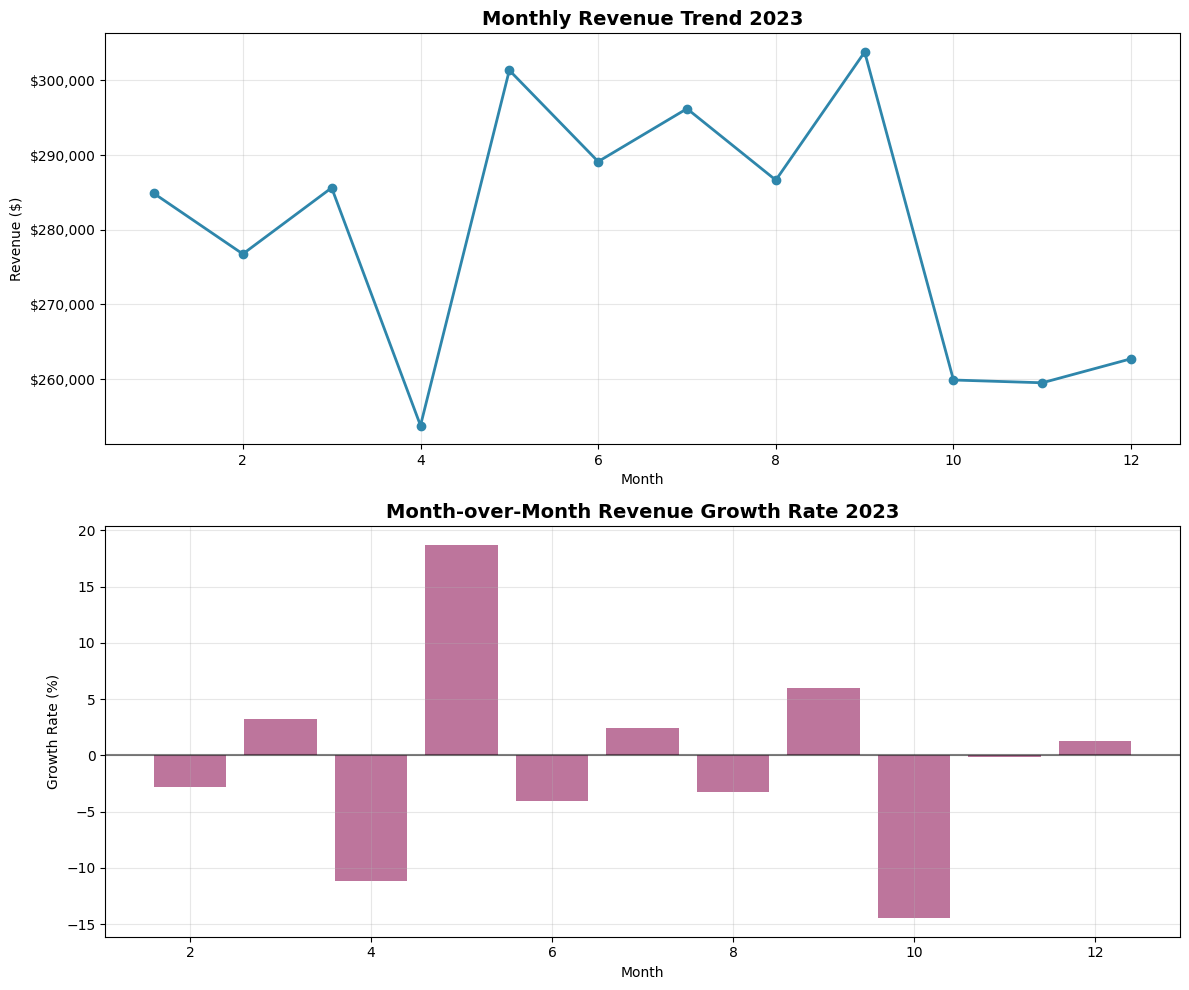

In [7]:
if ANALYSIS_MONTH is None:  # Only show monthly trends for full year analysis
    # Calculate monthly trends
    monthly_trends = calculate_monthly_trends(sales_with_delivery, ANALYSIS_YEAR)
    
    print(f"=== MONTHLY TRENDS {ANALYSIS_YEAR} ===")
    print(f"Average monthly revenue growth: {monthly_trends['revenue_growth'].mean():.2f}%")
    print(f"Best performing month: {monthly_trends.loc[monthly_trends['revenue'].idxmax(), 'month']}")
    print(f"Highest growth month: {monthly_trends.loc[monthly_trends['revenue_growth'].idxmax(), 'month']}")
    
    # Display monthly data
    display(monthly_trends.round(2))
    
    # Create trend visualization
    if SHOW_DETAILED_PLOTS:
        fig = plot_revenue_trend(monthly_trends, ANALYSIS_YEAR)
        plt.show()
else:
    print(f"Monthly trends not applicable for single month analysis ({ANALYSIS_YEAR}/{ANALYSIS_MONTH:02d})")

## 6. Product Performance Analysis

**Analysis of product category performance and revenue contribution**

In [8]:
# Create product sales dataset
product_sales_analysis = create_product_sales_data(analysis_data, products)
print(f"Product sales dataset: {len(product_sales_analysis):,} records")
print(f"Product categories: {product_sales_analysis['product_category_name'].nunique()}")

Product sales dataset: 7,448 records
Product categories: 13


### Product Category Performance

In [9]:
# Calculate category performance
category_performance = calculate_product_performance(product_sales_analysis)

print(f"=== TOP PRODUCT CATEGORIES {period_name.upper()} ===")
top_categories = category_performance.head(PLOT_TOP_N_CATEGORIES)

for idx, row in top_categories.iterrows():
    print(f"{row['product_category_name']}: ${row['total_revenue']:,.0f} ({row['revenue_percentage']:.1f}%)")

print(f"\nTop 3 categories account for {top_categories.head(3)['revenue_percentage'].sum():.1f}% of revenue")

# Display detailed metrics
print("\nDetailed Category Performance:")
display(category_performance.head(10))

=== TOP PRODUCT CATEGORIES 2023 ===
electronics: $1,401,359 (41.7%)
home_garden: $862,653 (25.7%)
sports_outdoors: $278,845 (8.3%)
automotive: $247,707 (7.4%)
clothing_shoes_jewelry: $232,745 (6.9%)
toys_games: $70,164 (2.1%)
health_personal_care: $65,370 (1.9%)
tools_home_improvement: $54,280 (1.6%)
beauty_personal_care: $49,213 (1.5%)
books_media: $38,559 (1.1%)

Top 3 categories account for 75.7% of revenue

Detailed Category Performance:


,product_category_name,total_revenue,avg_price,total_items,revenue_percentage
5,electronics,1401359.21,1056.04,1327,41.70
8,home_garden,862653.27,750.79,1149,25.67
10,sports_outdoors,278845.32,406.48,686,8.30
0,automotive,247707.10,506.56,489,7.37
4,clothing_shoes_jewelry,232745.04,263.29,884,6.93
12,toys_games,70163.64,147.40,476,2.09
7,health_personal_care,65370.27,103.76,630,1.95
11,tools_home_improvement,54280.33,247.86,219,1.62
2,beauty_personal_care,49213.30,156.23,315,1.46
3,books_media,38559.08,53.18,725,1.15


### Category Performance Visualization

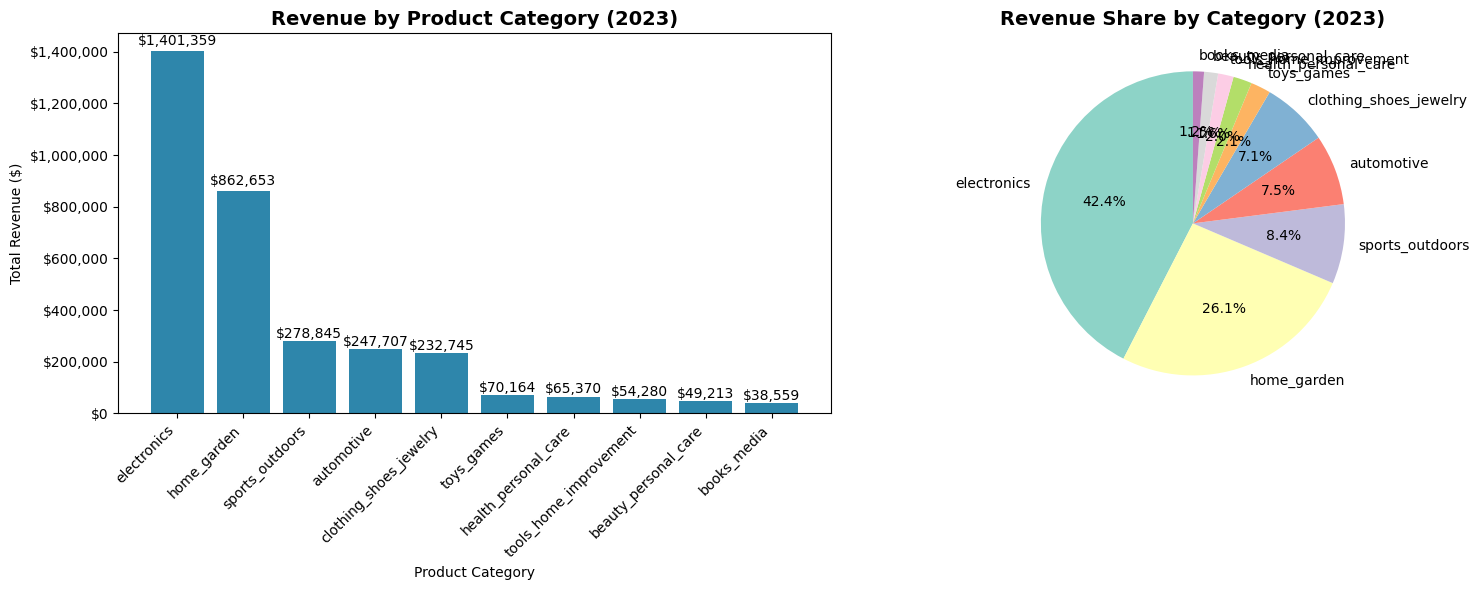

In [10]:
if SHOW_DETAILED_PLOTS:
    title_suffix = f" ({period_name})"
    fig = plot_category_performance(category_performance, title_suffix)
    plt.show()

## 7. Geographic Performance Analysis

**Analysis of sales performance across different states and regions**

In [11]:
# Create geographic sales dataset
geographic_sales = create_geographic_sales_data(analysis_data, orders_clean, customers)
print(f"Geographic sales dataset: {len(geographic_sales):,} records")
print(f"States covered: {geographic_sales['customer_state'].nunique()}")

Geographic sales dataset: 7,448 records
States covered: 20


### State-Level Performance

In [12]:
# Calculate geographic performance
state_performance = calculate_geographic_performance(geographic_sales)

print(f"=== TOP PERFORMING STATES {period_name.upper()} ===")
top_states = state_performance.head(PLOT_TOP_N_STATES)

for idx, row in top_states.head(10).iterrows():
    print(f"{row['state']}: ${row['total_revenue']:,.0f} ({row['total_orders']:,} orders, AOV: ${row['avg_order_value']:.0f})")

print(f"\nTop 5 states account for {top_states.head(5)['revenue_percentage'].sum():.1f}% of revenue")

# Display detailed metrics
print("\nDetailed State Performance:")
display(state_performance.head(15))

=== TOP PERFORMING STATES 2023 ===
CA: $537,881 (769 orders, AOV: $699)
TX: $403,303 (561 orders, AOV: $719)
FL: $310,196 (431 orders, AOV: $720)
NY: $253,112 (384 orders, AOV: $659)
IL: $185,931 (260 orders, AOV: $715)
PA: $173,261 (225 orders, AOV: $770)
OH: $157,620 (200 orders, AOV: $788)
GA: $146,415 (190 orders, AOV: $771)
MI: $132,326 (210 orders, AOV: $630)
NC: $128,315 (177 orders, AOV: $725)

Top 5 states account for 50.3% of revenue

Detailed State Performance:


,state,total_revenue,total_orders,avg_order_value,revenue_percentage
1,CA,537880.74,769,699.45,16.01
16,TX,403303.49,561,718.90,12.00
2,FL,310195.84,431,719.71,9.23
12,NY,253111.85,384,659.15,7.53
4,IL,185930.89,260,715.12,5.53
14,PA,173260.68,225,770.05,5.16
13,OH,157619.72,200,788.10,4.69
3,GA,146414.65,190,770.60,4.36
8,MI,132325.60,210,630.12,3.94
10,NC,128314.74,177,724.94,3.82


### Geographic Performance Visualization

**Interactive Map**: If plotly is installed, this will show an interactive US map with revenue data and hover information.

In [13]:
if SHOW_DETAILED_PLOTS:
    title_suffix = f" ({period_name})"
    fig = plot_geographic_performance(state_performance, title_suffix)
    plt.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 8. Customer Experience Analysis

**Analysis of customer satisfaction, delivery performance, and experience metrics**

In [ ]:
# Create review analysis dataset
review_analysis = create_review_analysis_data(analysis_data, reviews)
print(f"Review analysis dataset: {len(review_analysis):,} records")
print(f"Orders with reviews: {review_analysis['order_id'].nunique():,}")

Review analysis dataset: 3,225 records
Orders with reviews: 3,225


### Customer Satisfaction Metrics

In [ ]:
# Calculate satisfaction metrics
satisfaction_metrics = calculate_customer_satisfaction_metrics(review_analysis)

print(f"=== CUSTOMER SATISFACTION METRICS {period_name.upper()} ===")
print(f"Average Review Score: {satisfaction_metrics['average_review_score']:.2f}/5.0")
print(f"Total Reviews: {satisfaction_metrics['total_reviews']:,}")
print(f"Average Delivery Time: {satisfaction_metrics['average_delivery_days']:.1f} days")

print("\nReview Score Distribution:")
for score, percentage in satisfaction_metrics['review_distribution'].items():
    print(f"  {score} stars: {percentage:.1%}")

print("\nDelivery Speed Distribution:")
for category, percentage in satisfaction_metrics['delivery_category_distribution'].items():
    print(f"  {category}: {percentage:.1%}")

if 'satisfaction_by_delivery' in satisfaction_metrics:
    print("\nSatisfaction by Delivery Speed:")
    for category, avg_score in satisfaction_metrics['satisfaction_by_delivery'].items():
        print(f"  {category}: {avg_score:.2f}/5.0")

=== CUSTOMER SATISFACTION METRICS 2023 ===
Average Review Score: 4.10/5.0
Total Reviews: 3,225
Average Delivery Time: 8.0 days

Review Score Distribution:
  1 stars: 3.5%
  2 stars: 6.9%
  3 stars: 15.4%
  4 stars: 24.3%
  5 stars: 49.9%

Delivery Speed Distribution:
  8+ days: 55.6%
  4-7 days: 37.2%
  1-3 days: 7.2%

Satisfaction by Delivery Speed:
  1-3 days: 4.19/5.0
  4-7 days: 4.08/5.0
  8+ days: 4.11/5.0


### Customer Satisfaction Visualization

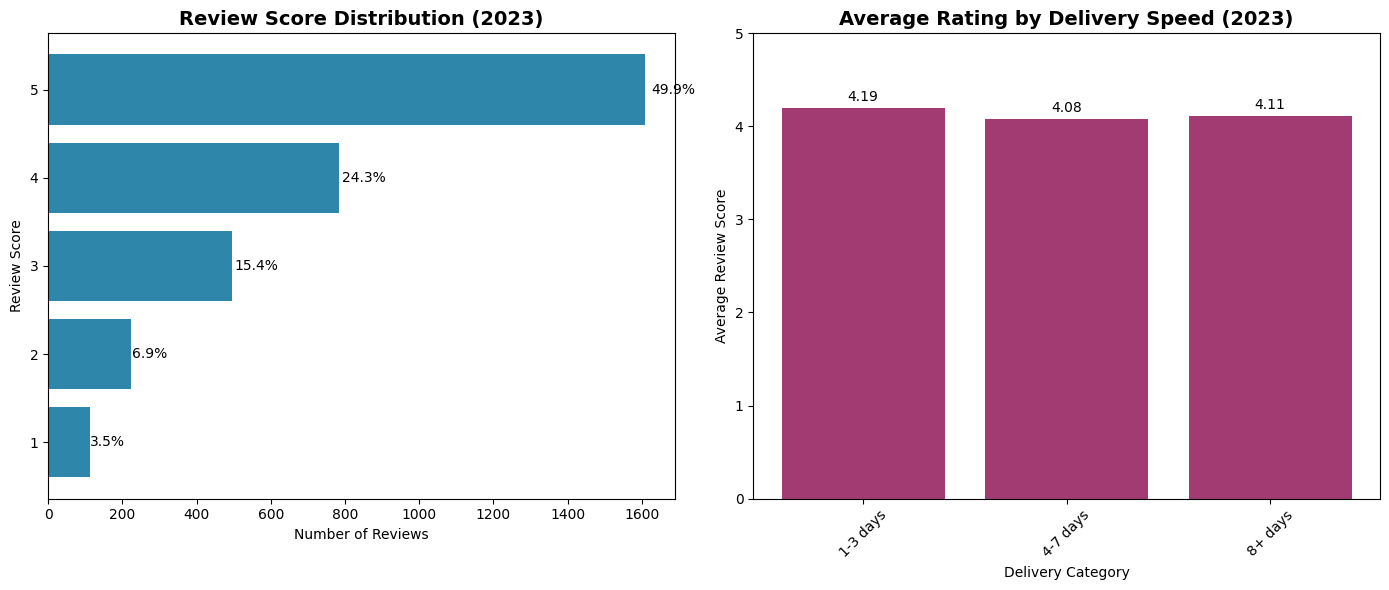

In [ ]:
if SHOW_DETAILED_PLOTS:
    title_suffix = f" ({period_name})"
    fig = plot_customer_satisfaction(review_analysis, title_suffix)
    plt.show()

## 9. Operational Performance Analysis

**Analysis of order fulfillment, delivery performance, and operational efficiency**

### Order Status Analysis

In [ ]:
# Filter orders for the analysis period
period_orders = filter_by_date_range(orders_clean, year=ANALYSIS_YEAR, month=ANALYSIS_MONTH)

# Calculate order status metrics
status_metrics = calculate_order_status_metrics(period_orders)

print(f"=== OPERATIONAL PERFORMANCE {period_name.upper()} ===")
print(f"Total Orders: {len(period_orders):,}")
print("\nOrder Status Distribution:")

for idx, row in status_metrics.iterrows():
    print(f"  {row['order_status']}: {row['count']:,} orders ({row['percentage']:.1f}%)")

# Calculate fulfillment rate (delivered + shipped vs canceled + returned)
successful_statuses = ['delivered', 'shipped']
failed_statuses = ['canceled', 'returned']

success_rate = status_metrics[
    status_metrics['order_status'].isin(successful_statuses)
]['percentage'].sum()

failure_rate = status_metrics[
    status_metrics['order_status'].isin(failed_statuses)
]['percentage'].sum()

print(f"\nFulfillment Success Rate: {success_rate:.1f}%")
print(f"Order Failure Rate: {failure_rate:.1f}%")

=== OPERATIONAL PERFORMANCE 2023 ===
Total Orders: 4,950

Order Status Distribution:
  delivered: 4,635 orders (93.6%)
  shipped: 158 orders (3.2%)
  canceled: 64 orders (1.3%)
  processing: 59 orders (1.2%)
  pending: 25 orders (0.5%)
  returned: 9 orders (0.2%)

Fulfillment Success Rate: 96.8%
Order Failure Rate: 1.5%


### Delivery Performance Deep Dive

In [ ]:
# Analyze delivery performance for delivered orders
delivered_orders = analysis_data[analysis_data['delivery_days'].notna()]

if len(delivered_orders) > 0:
    print(f"=== DELIVERY PERFORMANCE {period_name.upper()} ===")
    print(f"Orders with delivery data: {len(delivered_orders):,}")
    print(f"Average delivery time: {delivered_orders['delivery_days'].mean():.1f} days")
    print(f"Median delivery time: {delivered_orders['delivery_days'].median():.1f} days")
    print(f"Fastest delivery: {delivered_orders['delivery_days'].min():.0f} days")
    print(f"Slowest delivery: {delivered_orders['delivery_days'].max():.0f} days")
    
    # Delivery speed percentiles
    print("\nDelivery Time Percentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        value = np.percentile(delivered_orders['delivery_days'], p)
        print(f"  {p}th percentile: {value:.1f} days")
        
    # Delivery speed categories
    print("\nDelivery Speed Categories:")
    category_counts = delivered_orders['delivery_category'].value_counts()
    for category, count in category_counts.items():
        pct = count / len(delivered_orders) * 100
        print(f"  {category}: {count:,} orders ({pct:.1f}%)")
else:
    print("No delivery data available for the selected period")

=== DELIVERY PERFORMANCE 2023 ===
Orders with delivery data: 7,448
Average delivery time: 8.0 days
Median delivery time: 8.0 days
Fastest delivery: 2 days
Slowest delivery: 15 days

Delivery Time Percentiles:
  25th percentile: 6.0 days
  50th percentile: 8.0 days
  75th percentile: 10.0 days
  90th percentile: 12.0 days
  95th percentile: 13.0 days

Delivery Speed Categories:
  8+ days: 4,103 orders (55.1%)
  4-7 days: 2,815 orders (37.8%)
  1-3 days: 530 orders (7.1%)


## 10. Summary & Key Insights

**Comprehensive summary of findings and actionable business insights**

### Executive Summary

In [ ]:
print(f"=== EXECUTIVE SUMMARY - {period_name.upper()} ===")
print("\n" + "="*50)

# Revenue Summary
print("REVENUE PERFORMANCE:")
print(f"  Total Revenue: ${revenue_metrics['total_revenue']:,.0f}")
print(f"  Total Orders: {revenue_metrics['total_orders']:,}")
print(f"  Average Order Value: ${revenue_metrics['average_order_value']:.2f}")

if 'revenue_growth_rate' in revenue_metrics:
    print(f"  Revenue Growth (YoY): {revenue_metrics['revenue_growth_rate']:+.1f}%")
    print(f"  Order Growth (YoY): {revenue_metrics['order_growth_rate']:+.1f}%")
    print(f"  AOV Growth (YoY): {revenue_metrics['aov_growth_rate']:+.1f}%")

# Top Product Category
top_category = category_performance.iloc[0]
print(f"\nTOP PRODUCT CATEGORY:")
print(f"  {top_category['product_category_name']}: ${top_category['total_revenue']:,.0f} ({top_category['revenue_percentage']:.1f}%)")

# Top State
top_state = state_performance.iloc[0]
print(f"\nTOP PERFORMING STATE:")
print(f"  {top_state['state']}: ${top_state['total_revenue']:,.0f} ({top_state['revenue_percentage']:.1f}%)")

# Customer Experience
print(f"\nCUSTOMER EXPERIENCE:")
print(f"  Average Review Score: {satisfaction_metrics['average_review_score']:.2f}/5.0")
print(f"  Average Delivery Time: {satisfaction_metrics['average_delivery_days']:.1f} days")

# Operational Performance
delivered_pct = status_metrics[status_metrics['order_status'] == 'delivered']['percentage'].iloc[0]
print(f"\nOPERATIONAL PERFORMANCE:")
print(f"  Order Delivery Rate: {delivered_pct:.1f}%")
print(f"  Fulfillment Success Rate: {success_rate:.1f}%")

print("\n" + "="*50)

=== EXECUTIVE SUMMARY - 2023 ===

REVENUE PERFORMANCE:
  Total Revenue: $3,360,295
  Total Orders: 4,635
  Average Order Value: $724.98
  Revenue Growth (YoY): -2.5%
  Order Growth (YoY): -2.4%
  AOV Growth (YoY): -0.1%

TOP PRODUCT CATEGORY:
  electronics: $1,401,359 (41.7%)

TOP PERFORMING STATE:
  CA: $537,881 (16.0%)

CUSTOMER EXPERIENCE:
  Average Review Score: 4.10/5.0
  Average Delivery Time: 8.0 days

OPERATIONAL PERFORMANCE:
  Order Delivery Rate: 93.6%
  Fulfillment Success Rate: 96.8%



### Key Business Insights

In [ ]:
print("KEY BUSINESS INSIGHTS:")
print("\n1. REVENUE TRENDS:")

if 'revenue_growth_rate' in revenue_metrics:
    if revenue_metrics['revenue_growth_rate'] > 0:
        print(f"   - Revenue grew by {revenue_metrics['revenue_growth_rate']:.1f}% year-over-year")
        print(f"   - Order volume {'increased' if revenue_metrics['order_growth_rate'] > 0 else 'decreased'} by {abs(revenue_metrics['order_growth_rate']):.1f}%")
    else:
        print(f"   - Revenue declined by {abs(revenue_metrics['revenue_growth_rate']):.1f}% year-over-year")
        print(f"   - Order volume {'decreased' if revenue_metrics['order_growth_rate'] < 0 else 'increased'} by {abs(revenue_metrics['order_growth_rate']):.1f}%")
        
    if revenue_metrics['aov_growth_rate'] > 0:
        print(f"   - Average order value improved by {revenue_metrics['aov_growth_rate']:.1f}%")
    else:
        print(f"   - Average order value declined by {abs(revenue_metrics['aov_growth_rate']):.1f}%")

print("\n2. PRODUCT PERFORMANCE:")
top_3_categories = category_performance.head(3)
top_3_share = top_3_categories['revenue_percentage'].sum()
print(f"   - Top 3 categories drive {top_3_share:.1f}% of total revenue")
print(f"   - Leading category ({top_3_categories.iloc[0]['product_category_name']}) accounts for {top_3_categories.iloc[0]['revenue_percentage']:.1f}%")

# Category concentration analysis
if len(category_performance) > 5:
    bottom_categories = len(category_performance) - 5
    bottom_share = category_performance.tail(bottom_categories)['revenue_percentage'].sum()
    print(f"   - Bottom {bottom_categories} categories contribute only {bottom_share:.1f}% of revenue")

print("\n3. GEOGRAPHIC INSIGHTS:")
top_5_states = state_performance.head(5)
top_5_share = top_5_states['revenue_percentage'].sum()
print(f"   - Top 5 states generate {top_5_share:.1f}% of total revenue")
print(f"   - Leading state ({top_5_states.iloc[0]['state']}) contributes {top_5_states.iloc[0]['revenue_percentage']:.1f}%")

# AOV analysis by state
high_aov_states = state_performance[state_performance['avg_order_value'] > revenue_metrics['average_order_value']]
print(f"   - {len(high_aov_states)} states have above-average order values")

print("\n4. CUSTOMER EXPERIENCE:")
avg_score = satisfaction_metrics['average_review_score']
if avg_score >= 4.0:
    print(f"   - Strong customer satisfaction with {avg_score:.2f}/5.0 average rating")
else:
    print(f"   - Customer satisfaction needs improvement ({avg_score:.2f}/5.0 average rating)")

# Review score analysis
high_scores = satisfaction_metrics['review_distribution'][4] + satisfaction_metrics['review_distribution'][5]
low_scores = satisfaction_metrics['review_distribution'][1] + satisfaction_metrics['review_distribution'][2]
print(f"   - {high_scores:.1%} of reviews are 4-5 stars (positive)")
print(f"   - {low_scores:.1%} of reviews are 1-2 stars (negative)")

# Delivery performance insights
fast_delivery = satisfaction_metrics['delivery_category_distribution'].get('1-3 days', 0)
slow_delivery = satisfaction_metrics['delivery_category_distribution'].get('8+ days', 0)
print(f"   - {fast_delivery:.1%} of orders delivered in 1-3 days (excellent)")
print(f"   - {slow_delivery:.1%} of orders take 8+ days (needs improvement)")

print("\n5. OPERATIONAL EFFICIENCY:")
print(f"   - {delivered_pct:.1f}% of orders successfully delivered")
print(f"   - Overall fulfillment success rate: {success_rate:.1f}%")

if failure_rate > 5:
    print(f"   - Order failure rate of {failure_rate:.1f}% may indicate process issues")
else:
    print(f"   - Low order failure rate ({failure_rate:.1f}%) indicates efficient operations")

KEY BUSINESS INSIGHTS:

1. REVENUE TRENDS:
   - Revenue declined by 2.5% year-over-year
   - Order volume decreased by 2.4%
   - Average order value declined by 0.1%

2. PRODUCT PERFORMANCE:
   - Top 3 categories drive 75.7% of total revenue
   - Leading category (electronics) accounts for 41.7%
   - Bottom 8 categories contribute only 10.0% of revenue

3. GEOGRAPHIC INSIGHTS:
   - Top 5 states generate 50.3% of total revenue
   - Leading state (CA) contributes 16.0%
   - 11 states have above-average order values

4. CUSTOMER EXPERIENCE:
   - Strong customer satisfaction with 4.10/5.0 average rating
   - 74.2% of reviews are 4-5 stars (positive)
   - 10.4% of reviews are 1-2 stars (negative)
   - 7.2% of orders delivered in 1-3 days (excellent)
   - 55.6% of orders take 8+ days (needs improvement)

5. OPERATIONAL EFFICIENCY:
   - 93.6% of orders successfully delivered
   - Overall fulfillment success rate: 96.8%
   - Low order failure rate (1.5%) indicates efficient operations


### Strategic Recommendations

In [ ]:
print("STRATEGIC RECOMMENDATIONS:")

# Revenue-based recommendations
if 'revenue_growth_rate' in revenue_metrics and revenue_metrics['revenue_growth_rate'] < 0:
    print("\n1. REVENUE RECOVERY:")
    print("   - Investigate factors behind revenue decline")
    print("   - Consider promotional strategies to boost order volume")
    print("   - Focus on customer retention and repeat purchases")

# Product recommendations
print("\n2. PRODUCT STRATEGY:")
low_performers = category_performance.tail(3)
if len(low_performers) > 0:
    print(f"   - Evaluate underperforming categories: {', '.join(low_performers['product_category_name'].tolist())}")
    
top_performer = category_performance.iloc[0]
print(f"   - Expand inventory and marketing for top category: {top_performer['product_category_name']}")
print(f"   - Consider cross-selling opportunities between high and low performers")

# Geographic recommendations
print("\n3. GEOGRAPHIC EXPANSION:")
high_aov_low_volume = state_performance[
    (state_performance['avg_order_value'] > revenue_metrics['average_order_value']) & 
    (state_performance['total_orders'] < state_performance['total_orders'].median())
]

if len(high_aov_low_volume) > 0:
    print(f"   - Target high-AOV, low-volume states: {', '.join(high_aov_low_volume.head(3)['state'].tolist())}")
    print(f"   - Increase marketing efforts in underserved high-value markets")

# Customer experience recommendations
print("\n4. CUSTOMER EXPERIENCE:")
if satisfaction_metrics['average_review_score'] < 4.0:
    print("   - Implement customer satisfaction improvement program")
    print("   - Investigate root causes of negative reviews")

if satisfaction_metrics['average_delivery_days'] > 7:
    print("   - Optimize delivery logistics to reduce delivery times")
    print("   - Consider multiple fulfillment centers for faster delivery")

# Operational recommendations
print("\n5. OPERATIONAL IMPROVEMENTS:")
if failure_rate > 5:
    print(f"   - Address high order failure rate ({failure_rate:.1f}%)")
    print("   - Implement quality control measures to reduce cancellations")
    
slow_delivery_pct = satisfaction_metrics['delivery_category_distribution'].get('8+ days', 0)
if slow_delivery_pct > 0.3:
    print(f"   - {slow_delivery_pct:.1%} of deliveries are slow (8+ days) - optimize logistics")
    print("   - Consider premium shipping options for time-sensitive customers")

print("\n6. DATA & ANALYTICS:")
print("   - Implement real-time dashboards for key metrics monitoring")
print("   - Set up automated alerts for performance threshold breaches")
print("   - Conduct regular cohort analysis to understand customer behavior")
print("   - A/B test pricing and promotion strategies")

print("\n" + "="*60)
print(f"Analysis completed for {period_name}")
print(f"Total data points analyzed: {len(analysis_data):,}")
print(f"Report generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

STRATEGIC RECOMMENDATIONS:

1. REVENUE RECOVERY:
   - Investigate factors behind revenue decline
   - Consider promotional strategies to boost order volume
   - Focus on customer retention and repeat purchases

2. PRODUCT STRATEGY:
   - Evaluate underperforming categories: grocery_gourmet_food, baby_products, pet_supplies
   - Expand inventory and marketing for top category: electronics
   - Consider cross-selling opportunities between high and low performers

3. GEOGRAPHIC EXPANSION:
   - Target high-AOV, low-volume states: NJ, MA, AZ
   - Increase marketing efforts in underserved high-value markets

4. CUSTOMER EXPERIENCE:
   - Optimize delivery logistics to reduce delivery times
   - Consider multiple fulfillment centers for faster delivery

5. OPERATIONAL IMPROVEMENTS:
   - 55.6% of deliveries are slow (8+ days) - optimize logistics
   - Consider premium shipping options for time-sensitive customers

6. DATA & ANALYTICS:
   - Implement real-time dashboards for key metrics monitorin

---

## Appendix

### Configuration Used
- **Analysis Period**: 2023 (Full Year)
- **Comparison Period**: 2022 (Full Year) 
- **Data Source**: ecommerce_data

### Data Sources
- Orders Dataset: Raw order data with timestamps and status
- Order Items Dataset: Item-level pricing and product information
- Products Dataset: Product catalog with categories
- Customers Dataset: Customer geographic information
- Reviews Dataset: Customer review scores and feedback

### Technical Notes
- Only delivered orders are included in revenue calculations
- All currency amounts are in USD
- Delivery time is calculated from order purchase to customer delivery
- Review scores range from 1 (lowest) to 5 (highest)

---
*This analysis was generated using the refactored EDA framework with configurable parameters and reusable components.*